In [ ]:
#Install dependencies
!pip install transformers datasets seqeval torch -q
!pip install matplotlib
print('✅ Dependencies installed')


[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 27.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.0/325.0 kB 35.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 26.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 31.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.8/122.8 kB 32.2 MB/s eta 0:00:00

[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
✅ Dependencies installed


In [ ]:
#Imports and configuration
import json, random, gc, pickle
import numpy as np
import torch
import matplotlib.pyplot as plt
from collections import Counter
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW
from seqeval.metrics import (
    f1_score, precision_score, recall_score, classification_report
)
import warnings
warnings.filterwarnings('ignore')

#Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

#Hyperparameters
MAX_LEN = 128
BATCH   = 16
EPOCHS  = 10
LR      = 1e-5
WARMUP_RATIO   = 0.2
WEIGHT_DECAY   = 0.01
GRAD_CLIP      = 1.0

#Label set (BIO)
LABELS = ['O', 'B-SYM', 'I-SYM', 'B-DGN', 'I-DGN',
          'B-TMP', 'I-TMP', 'B-RF', 'I-RF']
L2I = {l: i for i, l in enumerate(LABELS)}
I2L = {i: l for l, i in L2I.items()}
NL  = len(LABELS)

#Device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    free, total = torch.cuda.mem_get_info()
    print(f'GPU memory: {free/1e9:.1f} GB free / {total/1e9:.1f} GB total')
print(f'Labels ({NL}): {LABELS}')

Device: cuda
GPU memory: 16.7 GB free / 16.9 GB total
Labels (9): ['O', 'B-SYM', 'I-SYM', 'B-DGN', 'I-DGN', 'B-TMP', 'I-TMP', 'B-RF', 'I-RF']


In [ ]:
import os

train_file = 'train_fixed.tsv'
val_file   = 'val_fixed.tsv'
test_file  = 'test_fixed.tsv'

def load_tsv_from_path(file_path):
    """Parse CoNLL-style BIO TSV from a given file path. Returns list of (tokens, labels) tuples."""
    sentences = []
    toks, labs = [], []
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line == '':
                if toks:
                    sentences.append((toks, labs))
                toks, labs = [], []
            else:
                parts = line.split('\t')
                if len(parts) == 2:
                    toks.append(parts[0])
                    labs.append(parts[1])
    if toks:
        sentences.append((toks, labs))
    return sentences

#Load data from the specified paths
train_data = load_tsv_from_path(train_file)
val_data   = load_tsv_from_path(val_file)
test_data  = load_tsv_from_path(test_file)

print(f'\nLoaded — Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}')

#Sanity check: label set
all_labels_found = set()
for sents in [train_data, val_data, test_data]:
    for _, labs in sents:
        all_labels_found.update(labs)
unexpected = all_labels_found - set(LABELS)
print(f'Unexpected labels: {unexpected if unexpected else "None"}')

Please ensure train_fixed.tsv, val_fixed.tsv, test_fixed.tsv are uploaded to the Colab /content/ directory (e.g., via drag & drop to the file browser).

Loaded — Train: 1211 | Val: 256 | Test: 275
Unexpected labels: None ✅


In [ ]:
#Dataset and tokenization
MODEL_NAME = 'indobenchmark/indobert-base-p2'
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)

def align_labels_with_tokens(sentences, tokenizer, max_len=MAX_LEN):
    """
    Tokenize word-split sentences and align BIO labels to subword tokens.
    Only the first subword token of each word receives the real label;
    continuation subword tokens and special tokens receive -100 (ignored in loss).
    """
    all_input_ids, all_attention_masks, all_labels = [], [], []

    for tokens, labels in sentences:
        encoding = tokenizer(
            tokens,
            is_split_into_words=True,
            max_length=max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        word_ids     = encoding.word_ids(batch_index=0)
        aligned_labs = []
        prev_word_id = None
        for word_id in word_ids:
            if word_id is None:
                # Special token ([CLS], [SEP], [PAD])
                aligned_labs.append(-100)
            elif word_id != prev_word_id:
                # First subword of a word — use the real label
                lab = labels[word_id] if word_id < len(labels) else 'O'
                aligned_labs.append(L2I.get(lab, L2I['O']))
            else:
                # Continuation subword — ignore in loss
                aligned_labs.append(-100)
            prev_word_id = word_id

        all_input_ids.append(encoding['input_ids'].squeeze())
        all_attention_masks.append(encoding['attention_mask'].squeeze())
        all_labels.append(torch.tensor(aligned_labs))

    return all_input_ids, all_attention_masks, all_labels


class NERDataset(Dataset):
    def __init__(self, sentences, tokenizer, max_len=MAX_LEN):
        self.input_ids, self.attention_masks, self.labels = \
            align_labels_with_tokens(sentences, tokenizer, max_len)

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return {
            'input_ids':      self.input_ids[idx],
            'attention_mask': self.attention_masks[idx],
            'labels':         self.labels[idx]
        }


train_dataset = NERDataset(train_data, tokenizer)
val_dataset   = NERDataset(val_data,   tokenizer)
test_dataset  = NERDataset(test_data,  tokenizer)

train_loader = DataLoader(train_dataset, batch_size=BATCH, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH)

print(f'Tokenizer: {MODEL_NAME}')
print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}')

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Tokenizer: indobenchmark/indobert-base-p2
Train batches: 76 | Val batches: 16 | Test batches: 18


In [ ]:
#Model
model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NL,
    id2label=I2L,
    label2id=L2I,
    ignore_mismatched_sizes=True
).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model: {MODEL_NAME}')
print(f'Total parameters:     {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')

[transformers] You passed `num_labels=9` which is incompatible to the `id2label` map of length `5`.


pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForTokenClassification LOAD REPORT from: indobenchmark/indobert-base-p2
Key                 | Status     | 
--------------------+------------+-
pooler.dense.bias   | UNEXPECTED | 
pooler.dense.weight | UNEXPECTED | 
classifier.weight   | MISSING    | 
classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model: indobenchmark/indobert-base-p2
Total parameters:     123,857,673
Trainable parameters: 123,857,673


In [ ]:
#Optimizer and scheduler
no_decay = ['bias', 'LayerNorm.weight']
optimizer_grouped_parameters = [
    {
        'params': [p for n, p in model.named_parameters()
                   if not any(nd in n for nd in no_decay)],
        'weight_decay': WEIGHT_DECAY
    },
    {
        'params': [p for n, p in model.named_parameters()
                   if     any(nd in n for nd in no_decay)],
        'weight_decay': 0.0
    }
]
optimizer = AdamW(optimizer_grouped_parameters, lr=LR)

total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(WARMUP_RATIO * total_steps)
scheduler    = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f'Total training steps: {total_steps}')
print(f'Warmup steps:         {warmup_steps}')

Total training steps: 760
Warmup steps:         152


In [ ]:
#Evaluation function
def evaluate(model, loader):
    """
    Span-level evaluation using seqeval.
    Returns macro F1, precision, recall, predicted sequences, gold sequences.
    """
    model.eval()
    all_preds, all_golds = [], []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            labels         = batch['labels'].to(DEVICE)

            logits = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            ).logits
            preds = torch.argmax(logits, dim=-1)

            for pred_seq, gold_seq in zip(preds, labels):
                pred_tags, gold_tags = [], []
                for p, g in zip(pred_seq, gold_seq):
                    if g.item() == -100:
                        continue   # skip special/subword tokens
                    pred_tags.append(I2L[p.item()])
                    gold_tags.append(I2L[g.item()])
                all_preds.append(pred_tags)
                all_golds.append(gold_tags)

    macro_f1   = f1_score(all_golds,       all_preds, average='macro',  zero_division=0)
    macro_prec = precision_score(all_golds, all_preds, average='macro',  zero_division=0)
    macro_rec  = recall_score(all_golds,   all_preds, average='macro',  zero_division=0)

    return macro_f1, macro_prec, macro_rec, all_preds, all_golds

In [ ]:
#Training loop
best_val_f1    = 0.0
best_weights   = None
history        = []

print(f'MODEL 1: IndoBERT-base + Linear')
print(f'Epochs: {EPOCHS} | LR: {LR} | Batch: {BATCH} | MaxLen: {MAX_LEN}')

for epoch in range(EPOCHS):
    #Training
    model.train()
    running_loss = 0.0

    for step, batch in enumerate(train_loader):
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels         = batch['labels'].to(DEVICE)

        optimizer.zero_grad()

        loss = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        ).loss

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        scheduler.step()

        running_loss += loss.item()

        if (step + 1) % 20 == 0:
            print(f'  Epoch {epoch+1} | Step {step+1}/{len(train_loader)} '
                  f'| Loss: {running_loss / (step+1):.4f}')

    avg_loss = running_loss / len(train_loader)

    #Validation
    val_f1, val_prec, val_rec, _, _ = evaluate(model, val_loader)

    print(f'\nEpoch {epoch+1}/{EPOCHS} '
          f'| Train Loss: {avg_loss:.4f} '
          f'| Val F1: {val_f1:.4f} '
          f'| Val P: {val_prec:.4f} '
          f'| Val R: {val_rec:.4f}')

    history.append({
        'epoch':    epoch + 1,
        'loss':     avg_loss,
        'val_f1':   val_f1,
        'val_prec': val_prec,
        'val_rec':  val_rec
    })

    #Save best checkpoint
    if val_f1 > best_val_f1:
        best_val_f1  = val_f1
        best_weights = {k: v.clone() for k, v in model.state_dict().items()}
        print(f'  ✅ New best val F1: {best_val_f1:.4f}')
    print()

#Restore best checkpoint before test evaluation
if best_weights:
    model.load_state_dict(best_weights)

print(f'Training complete. Best val F1: {best_val_f1:.4f}')

MODEL 1: IndoBERT-base + Linear
Epochs: 10 | LR: 1e-05 | Batch: 16 | MaxLen: 128
  Epoch 1 | Step 20/76 | Loss: 2.1520
  Epoch 1 | Step 40/76 | Loss: 1.7302
  Epoch 1 | Step 60/76 | Loss: 1.4222

Epoch 1/10 | Train Loss: 1.2445 | Val F1: 0.3390 | Val P: 0.3340 | Val R: 0.3468
  ✅ New best val F1: 0.3390

  Epoch 2 | Step 20/76 | Loss: 0.4268
  Epoch 2 | Step 40/76 | Loss: 0.3787
  Epoch 2 | Step 60/76 | Loss: 0.3421

Epoch 2/10 | Train Loss: 0.3244 | Val F1: 0.6696 | Val P: 0.6244 | Val R: 0.7292
  ✅ New best val F1: 0.6696

  Epoch 3 | Step 20/76 | Loss: 0.2307
  Epoch 3 | Step 40/76 | Loss: 0.2244
  Epoch 3 | Step 60/76 | Loss: 0.2123

Epoch 3/10 | Train Loss: 0.2088 | Val F1: 0.7229 | Val P: 0.7021 | Val R: 0.7465
  ✅ New best val F1: 0.7229

  Epoch 4 | Step 20/76 | Loss: 0.1658
  Epoch 4 | Step 40/76 | Loss: 0.1655
  Epoch 4 | Step 60/76 | Loss: 0.1587

Epoch 4/10 | Train Loss: 0.1587 | Val F1: 0.7238 | Val P: 0.7047 | Val R: 0.7449
  ✅ New best val F1: 0.7238

  Epoch 5 | Step 20

In [ ]:
#Test evaluation
test_f1, test_prec, test_rec, test_preds, test_golds = evaluate(model, test_loader)

print('MODEL 1 TEST RESULTS — IndoBERT-base + Linear')
print(f'Macro F1:        {test_f1:.4f}')
print(f'Macro Precision: {test_prec:.4f}')
print(f'Macro Recall:    {test_rec:.4f}')
print()
print(classification_report(test_golds, test_preds, zero_division=0))

#Collect per-entity scores for plots/saving
report_dict = classification_report(
    test_golds, test_preds, output_dict=True, zero_division=0
)
per_entity = {
    ent: {
        'prec': report_dict[ent]['precision'],
        'rec':  report_dict[ent]['recall'],
        'f1':   report_dict[ent]['f1-score']
    }
    for ent in ['DGN', 'RF', 'SYM', 'TMP']
}

results = {
    'model':      'IndoBERT-base+Linear',
    'overall':    {'f1': test_f1, 'prec': test_prec, 'rec': test_rec},
    'per_entity': per_entity,
    'history':    history
}

MODEL 1 TEST RESULTS — IndoBERT-base + Linear
Macro F1:        0.7367
Macro Precision: 0.6976
Macro Recall:    0.7818

              precision    recall  f1-score   support

         DGN       0.84      0.92      0.88       354
          RF       0.72      0.75      0.73       134
         SYM       0.62      0.72      0.67       436
         TMP       0.61      0.74      0.67       171

   micro avg       0.70      0.79      0.74      1095
   macro avg       0.70      0.78      0.74      1095
weighted avg       0.70      0.79      0.74      1095



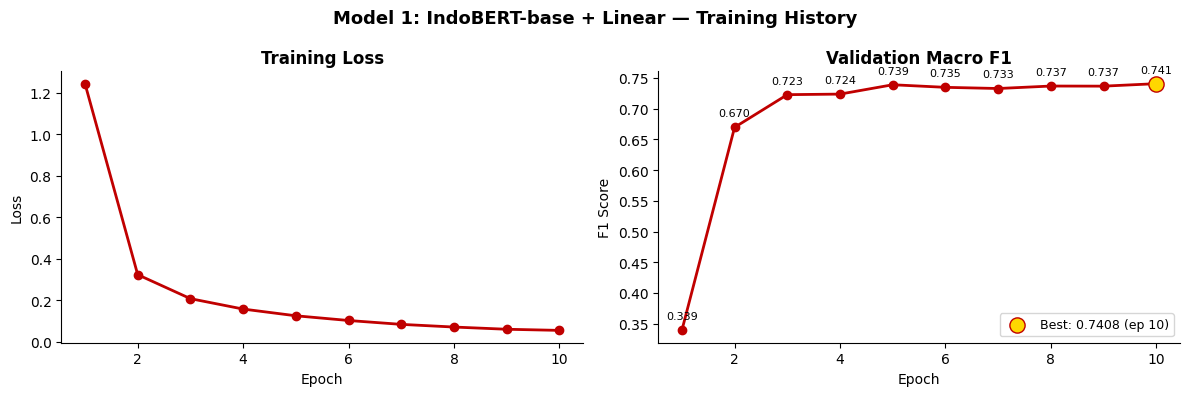

✅ Saved: m1_training_curves.png


In [ ]:
#Figure 1 Training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Model 1: IndoBERT-base + Linear — Training History',
             fontsize=13, fontweight='bold')

epochs_x = [h['epoch'] for h in history]
COLOR = '#C00000'

#Loss
axes[0].plot(epochs_x, [h['loss']   for h in history],
             'o-', color=COLOR, lw=2, markersize=6)
axes[0].set_title('Training Loss', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')

#Validation F1
axes[1].plot(epochs_x, [h['val_f1'] for h in history],
             'o-', color=COLOR, lw=2, markersize=6)
best_ep = max(history, key=lambda h: h['val_f1'])
axes[1].scatter([best_ep['epoch']], [best_ep['val_f1']],
                color='gold', s=120, zorder=5, edgecolors=COLOR,
                label=f"Best: {best_ep['val_f1']:.4f} (ep {best_ep['epoch']})")
axes[1].legend(fontsize=9)
for h in history:
    axes[1].annotate(f"{h['val_f1']:.3f}",
                     (h['epoch'], h['val_f1']),
                     textcoords='offset points', xytext=(0, 8),
                     ha='center', fontsize=8)
axes[1].set_title('Validation Macro F1', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('F1 Score')

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('m1_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: m1_training_curves.png')

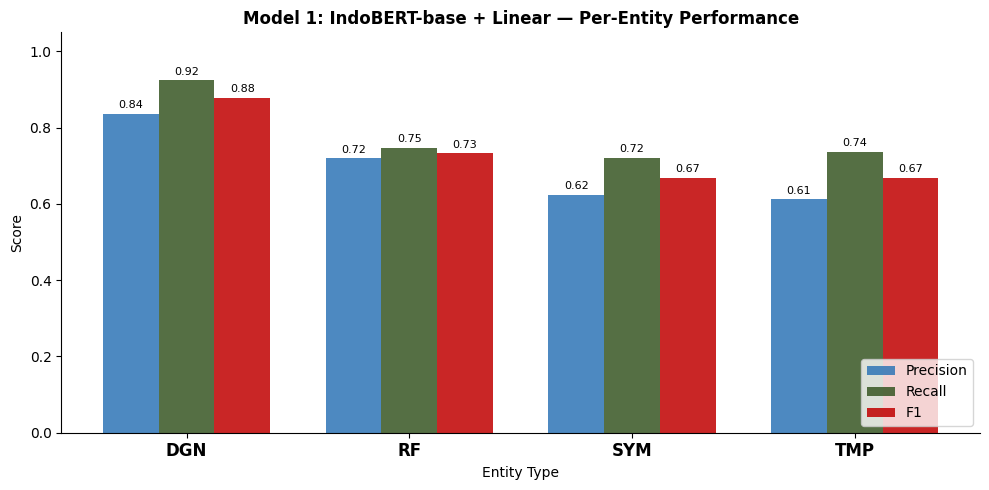

✅ Saved: m1_per_entity.png


In [ ]:
#Figure 2 Per-entity performance
ENTITIES = ['DGN', 'RF', 'SYM', 'TMP']
x = np.arange(len(ENTITIES))
w = 0.25

prec_vals = [per_entity[e]['prec'] for e in ENTITIES]
rec_vals  = [per_entity[e]['rec']  for e in ENTITIES]
f1_vals   = [per_entity[e]['f1']   for e in ENTITIES]

fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - w, prec_vals, w, label='Precision', color='#2E75B6', alpha=0.85)
b2 = ax.bar(x,     rec_vals,  w, label='Recall',    color='#375623', alpha=0.85)
b3 = ax.bar(x + w, f1_vals,   w, label='F1',        color='#C00000', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(ENTITIES, fontsize=12, fontweight='bold')
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score'); ax.set_xlabel('Entity Type')
ax.set_title('Model 1: IndoBERT-base + Linear — Per-Entity Performance',
             fontweight='bold')
ax.legend(loc='lower right')

for bars in [b1, b2, b3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01,
                f'{bar.get_height():.2f}',
                ha='center', va='bottom', fontsize=8)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('m1_per_entity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: m1_per_entity.png')

In [ ]:
import os
os.makedirs('/home/misel/stroke_ner/outputs/v2', exist_ok=True)
print('Folder ready:', os.listdir('/home/misel/stroke_ner/outputs'))

✅ Folder ready: ['v2']


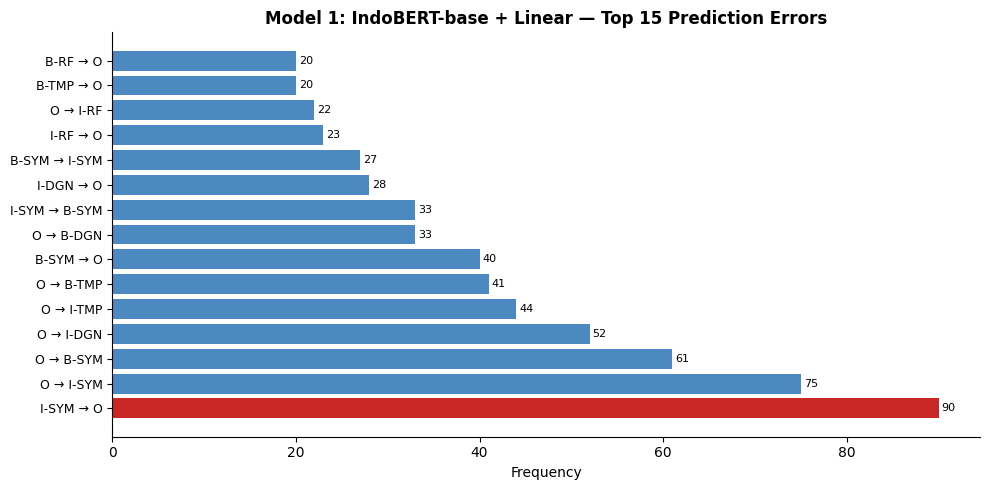

✅ Saved: m1_errors.png


In [ ]:
#Figure 3 Top prediction errors
error_counts = Counter()
for gold_seq, pred_seq in zip(test_golds, test_preds):
    for g, p in zip(gold_seq, pred_seq):
        if g != p:
            error_counts[(g, p)] += 1

top15 = error_counts.most_common(15)

if top15:
    labels_str = [f'{g} → {p}' for (g, p), _ in top15]
    counts     = [v for _, v in top15]

    fig, ax = plt.subplots(figsize=(10, 5))
    colors = ['#C00000' if v == max(counts) else '#2E75B6' for v in counts]
    bars   = ax.barh(range(len(top15)), counts, color=colors, alpha=0.85)

    ax.set_yticks(range(len(top15)))
    ax.set_yticklabels(labels_str, fontsize=9)
    ax.set_xlabel('Frequency')
    ax.set_title('Model 1: IndoBERT-base + Linear — Top 15 Prediction Errors',
                 fontweight='bold')

    for bar, val in zip(bars, counts):
        ax.text(bar.get_width() + 0.3,
                bar.get_y() + bar.get_height() / 2,
                str(val), va='center', fontsize=8)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.savefig('m1_errors.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: m1_errors.png')
else:
    print('No errors found.')

In [ ]:
import os
print(os.path.expanduser('~'))
print(os.getcwd())

/home/misel
/home/misel


In [ ]:
#Save to local server
import os, shutil, pickle, json

SAVE_DIR = '/home/misel/stroke_ner/outputs/v2/m1_indobert_linear'
os.makedirs(SAVE_DIR, exist_ok=True)

#Save model and tokenizer
model.save_pretrained(os.path.join(SAVE_DIR, 'model'))
tokenizer.save_pretrained(os.path.join(SAVE_DIR, 'model'))

#save results
with open(os.path.join(SAVE_DIR, 'session1_results.pkl'), 'wb') as f:
    pickle.dump(results, f)
with open(os.path.join(SAVE_DIR, 'session1_results.json'), 'w') as f:
    json.dump({
        'model':      results['model'],
        'overall':    results['overall'],
        'per_entity': results['per_entity']
    }, f, indent=2)

#Save figures
for fname in ['m1_training_curves.png', 'm1_per_entity.png', 'm1_errors.png']:
    if os.path.exists(fname):
        shutil.copy(fname, os.path.join(SAVE_DIR, fname))

print(f'All outputs saved to: {SAVE_DIR}')
print(f'\nFINAL RESULTS — IndoBERT-base + Linear (v2)')
print(f'  Macro F1:        {test_f1:.4f}')
print(f'  Macro Precision: {test_prec:.4f}')
print(f'  Macro Recall:    {test_rec:.4f}')
print()
for e in ['DGN', 'RF', 'SYM', 'TMP']:
    pe = per_entity[e]
    print(f'  {e}: F1={pe["f1"]:.4f}  P={pe["prec"]:.4f}  R={pe["rec"]:.4f}')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ All outputs saved to: /home/misel/stroke_ner/outputs/v2/m1_indobert_linear

FINAL RESULTS — IndoBERT-base + Linear (v2)
  Macro F1:        0.7367
  Macro Precision: 0.6976
  Macro Recall:    0.7818

  DGN: F1=0.8779  P=0.8363  R=0.9237
  RF: F1=0.7326  P=0.7194  R=0.7463
  SYM: F1=0.6681  P=0.6230  R=0.7202
  TMP: F1=0.6684  P=0.6117  R=0.7368
